In [19]:
import numpy as np
import os
import seaborn as sb
import globals as gl
import pingouin as pg
import PcmPy as pcm
from pcm_models import find_model
import matplotlib.pyplot as plt
import pickle
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from sklearn.preprocessing import MinMaxScaler
import nibabel as nb
import nitools as nt

plt.style.use('default')

In [20]:
experiment = 'smp2'
glm = 12
H = 'R'
rois = gl.rois['ROI']

SMA: tval=6.603454412612721, pval=8.531195933862835e-06
PMd: tval=4.9020576386680474, pval=0.0001445182348867795
PMv: tval=3.899467920267007, pval=0.0009140049233959864
M1: tval=4.88669546463512, pval=0.00014852627187375355
S1: tval=4.370633869006089, pval=0.0003787903052004493
SPLa: tval=3.8443293822321634, pval=0.001014614522804246
SPLp: tval=9.825763838175863, pval=1.1027165525620616e-07


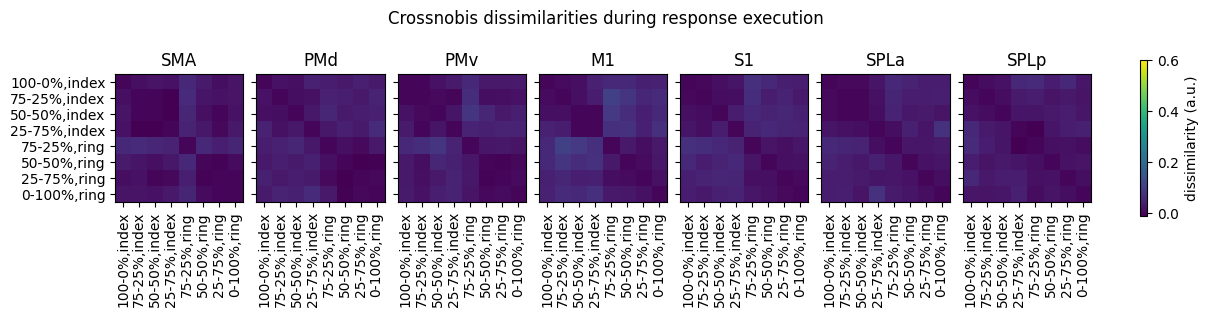

In [21]:
from vis import plot_dissimilarities

vmin, vmax = -.01, .6

fig, axs = plt.subplots(1, len(rois), figsize=(12, 3),sharex=True, sharey=True, constrained_layout=True)
for r, roi in enumerate(rois):
    G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    fig, axs = plot_dissimilarities(fig, axs, r, D, list(gl.regressor_mapping.keys())[5:], vmin=vmin, vmax=vmax, sqrt=False, source=roi)
    axs[r].set_title(roi)
cax = axs[-1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.008)
cbar.set_label('dissimilarity (a.u.)')
fig.suptitle('Crossnobis dissimilarities during response execution')

plt.show()

                                       T  dof alternative     p-val  \
roi  component                                                        
M1   expectation   T-test      -2.020712   13     greater  0.967798   
     sensory input T-test       1.910436   13     greater  0.039192   
     surprise      T-test       3.374902   13     greater  0.002488   
PMd  expectation   T-test     -14.385985   13     greater  1.000000   
     sensory input T-test       1.483381   13     greater  0.080904   
     surprise      T-test       4.672288   13     greater  0.000218   
PMv  expectation   T-test -470345.682744   13     greater  1.000000   
     sensory input T-test       1.149842   13     greater  0.135462   
     surprise      T-test       3.530478   13     greater  0.001846   
S1   expectation   T-test      -7.424233   13     greater  0.999997   
     sensory input T-test       1.588955   13     greater  0.068043   
     surprise      T-test       3.230900   13     greater  0.003283   
SMA  e

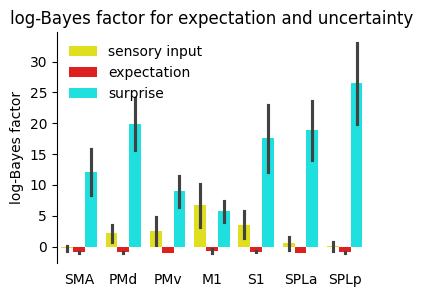

In [22]:
df = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.pcmDir, 'component_model.tsv'), sep='\t')
df = df[(df['epoch']=='exec') & (df['Hem']==H)]
fig, ax = plt.subplots(figsize=(4, 3))
sb.barplot(ax=ax, data=df, x='roi', y='BF', hue='component', palette = ['#FFFF00', 'red', 'cyan'], errorbar='se')
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('log-Bayes factor')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('log-Bayes factor for expectation and uncertainty')
results = df.groupby(['roi', 'component']).BF.apply(lambda x: pg.ttest(x, 0, alternative='greater'))
print(results)
plt.show()

         Contrast              A              B  Paired  Parametric         T  \
roi                                                                             
M1   0  component    expectation  sensory input    True        True -3.477255   
     1  component    expectation       surprise    True        True -5.563150   
     2  component  sensory input       surprise    True        True -0.335189   
PMd  0  component    expectation  sensory input    True        True -1.899898   
     1  component    expectation       surprise    True        True -6.818792   
     2  component  sensory input       surprise    True        True -5.237771   
PMv  0  component    expectation  sensory input    True        True -2.790135   
     1  component    expectation       surprise    True        True -7.451298   
     2  component  sensory input       surprise    True        True -2.667070   
S1   0  component    expectation  sensory input    True        True -2.117576   
     1  component    expecta

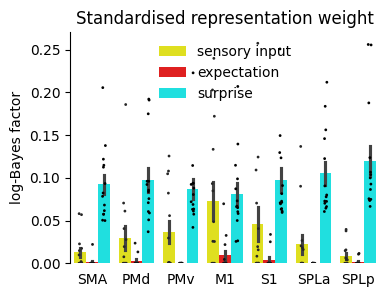

In [23]:
fig, ax = plt.subplots(figsize=(4, 3))
sb.barplot(ax=ax, data=df, x='roi', y='weight', hue='component', palette = ['#FFFF00', 'red', 'cyan'], errorbar='se')
sb.stripplot(ax=ax, data=df, x='roi', y='weight', hue='component', size=2, color='black', jitter=.1, dodge=True, legend=False)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('log-Bayes factor')
ax.tick_params(axis='x', bottom=False,)
ax.legend(title=None, frameon=False)
ax.set_title('Standardised representation weight')
res = df.groupby('roi').apply(lambda g: pg.pairwise_tests(data=g, dv='weight', within='component', subject='participant_id'))
print(res)
plt.show()

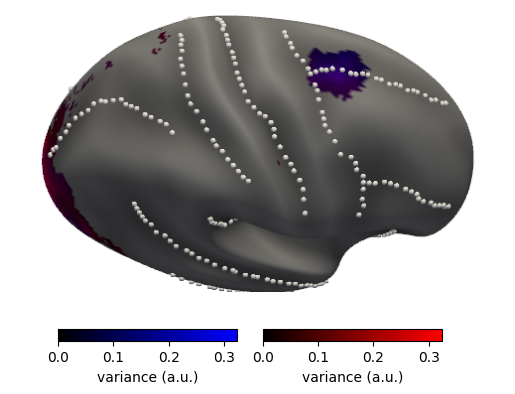

In [24]:
from vis import plot_surf

mclip = .2
threshold = .05 / mclip
scaler = MinMaxScaler()

gifti = nb.load(os.path.join(gl.baseDir, experiment, gl.wbDir, f'searchlight.var_expl.plan.{H}.func.gii'))
data = nt.get_gifti_data_matrix(gifti)
raw_max = np.nanmax(data)
data = data / raw_max#scaler.fit_transform(data)
raw_min = 0 #scaler.inverse_transform([[threshold * mclip, threshold * mclip]])[0,0]
data = np.clip(data / mclip, 0, 1)

sulc = nt.get_gifti_data_matrix(nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.LR.sulc.dscalar.gii'))
sulc = sulc[:len(data)]
sulc_norm = MinMaxScaler((0.3, 0.7)).fit_transform(sulc.reshape(-1, 1)).flatten()

rgba = np.zeros((len(sulc_norm), 4))
rgba[:, 0] = sulc_norm  # red = grey
rgba[:, 1] = sulc_norm  # green = grey
rgba[:, 2] = sulc_norm  # blue = grey
rgba[:, 3] = 1.0        # opaque background

overlay_mask = (data[:, 0] >= threshold) | (data[:, 1] >= threshold)

rgba[overlay_mask, 0] = data[overlay_mask, 0]  # red
rgba[overlay_mask, 1] = 0                    # green stays off for 2-color blend
rgba[overlay_mask, 2] = data[overlay_mask, 1]  # blue
rgba[overlay_mask, 3] = 1.0                     # alpha: opaque overlay
rgba[~overlay_mask, 3] = 1.0                    # still show grey background

fig, ax = plt.subplots()
fig, ax = plot_surf(fig, ax, rgba, H, cmap=None, vmin=None, vmax=None, overlay='rgb')

blue_half = LinearSegmentedColormap.from_list("blue_half", ["black", "blue"])
neg_norm = Normalize(vmin=raw_min, vmax=raw_max)
sm_neg = ScalarMappable(norm=neg_norm, cmap=blue_half)

red_half = LinearSegmentedColormap.from_list("red_half", ["black", "red"])
pos_norm = Normalize(vmin=raw_min, vmax=raw_max)
sm_pos = ScalarMappable(norm=pos_norm, cmap=red_half)

cax_neg = fig.add_axes([0.20, 0.10, 0.28, 0.025])  # left (blue)
cax_pos = fig.add_axes([0.52, 0.10, 0.28, 0.025])  # right (red)

cbar_neg = fig.colorbar(sm_neg, cax=cax_neg, orientation='horizontal')
cbar_pos = fig.colorbar(sm_pos, cax=cax_pos, orientation='horizontal')

cbar_neg.set_label('variance (a.u.)')
cbar_pos.set_label('variance (a.u.)')

plt.show()